In [27]:
import pandas as pd

columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

In [28]:
df1 = pd.read_csv('bezdekIris.data', names=columns)
df1 = df1.dropna().reset_index(drop=True)

print("bezdekIris.data:")
df1.head()

bezdekIris.data:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [29]:
df2 = pd.read_csv('iris.data', names=columns)
df2 = df2.dropna().reset_index(drop=True)

print("\niris.data:")
df2.head()


iris.data:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [30]:
df = pd.concat([df1, df2], ignore_index=True)

print("\nCombined Dataset Shape:", df.shape)
df.head()


Combined Dataset Shape: (300, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [31]:
df.info()
df.describe()
df['species'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  300 non-null    float64
 1   sepal_width   300 non-null    float64
 2   petal_length  300 non-null    float64
 3   petal_width   300 non-null    float64
 4   species       300 non-null    object 
dtypes: float64(4), object(1)
memory usage: 11.8+ KB


,count
species,
Iris-setosa,100
Iris-versicolor,100
Iris-virginica,100


In [32]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [33]:
df = df.dropna()

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['species'] = le.fit_transform(df['species'])

In [35]:
X = df.drop('species', axis=1)
y = df['species']

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

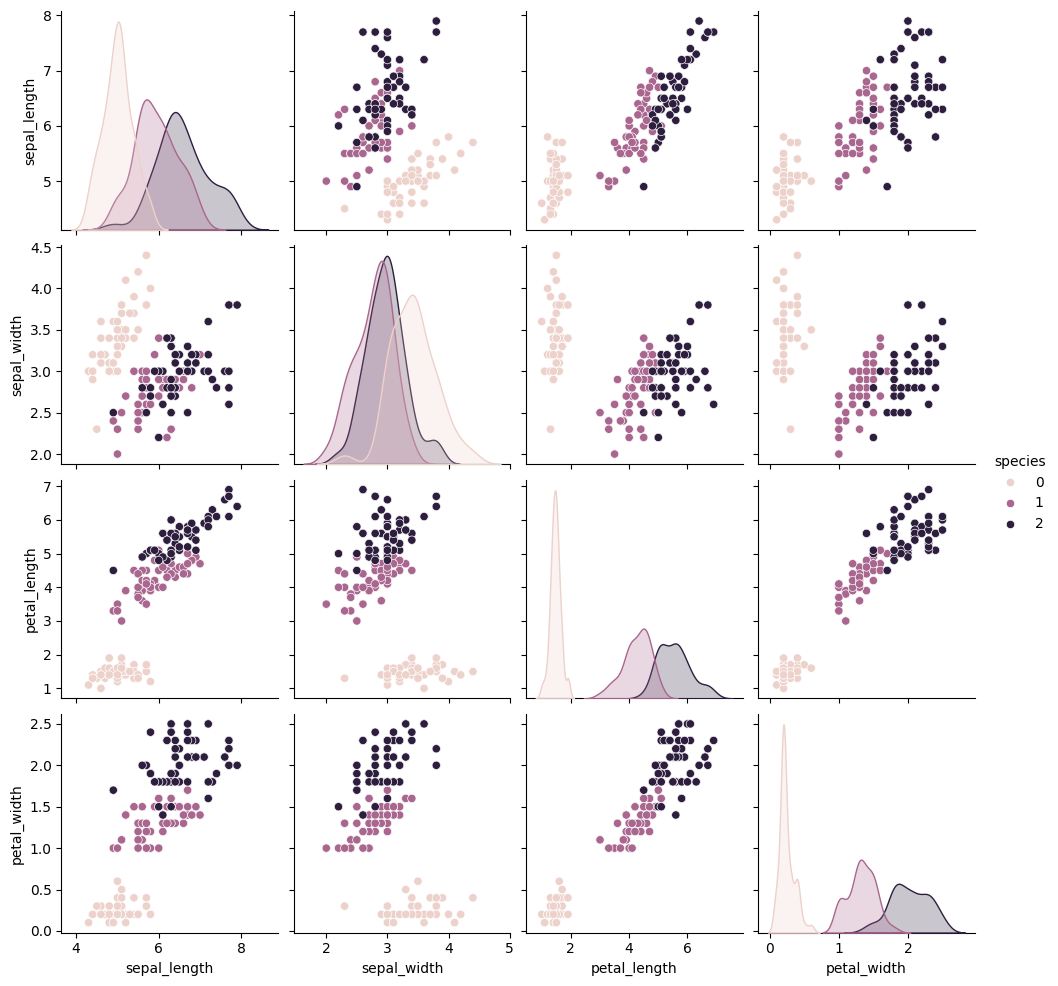

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue='species')
plt.show()

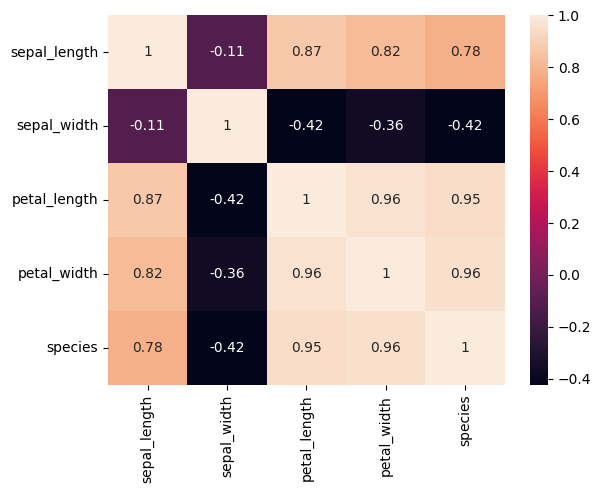

In [39]:
sns.heatmap(df.corr(), annot=True)
plt.show()

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [41]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9666666666666667


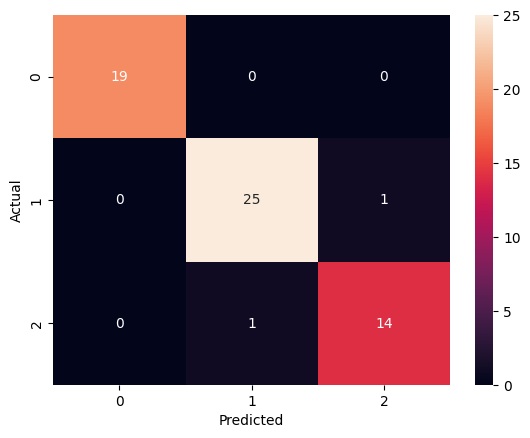

In [42]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.96      0.96      0.96        26
           2       0.93      0.93      0.93        15

    accuracy                           0.97        60
   macro avg       0.96      0.96      0.96        60
weighted avg       0.97      0.97      0.97        60

